# Working with JuPedSim Web-UI Scenarios in Python

Load scenario JSON files exported from the web UI and run them programmatically.

**Workflow:**
1. Design your scenario in the web UI (geometry, exits, distributions, etc.)
2. Export the scenario as ZIP
3. Load it here, inspect/modify, run, and analyze

In [ ]:
from jupedsim_scenario import load_scenario, run_scenario

## 1. Load and inspect a scenario

In [ ]:
scenario = load_scenario("scenarios/jps_2026_03_07_10_54_07.zip")
print(scenario.summary())

## 2. Modify parameters before running

In [ ]:
scenario.set_agent_count("jps-distributions_0", 20)
scenario.set_max_time(60)
print(scenario.summary())

## 3. Run the simulation

In [30]:
result = run_scenario(scenario)

print(f"Success:          {result.success}")
print(f"Evacuation time:  {result.evacuation_time:.2f}s")
print(f"Total agents:     {result.total_agents}")
print(f"Evacuated:        {result.agents_evacuated}")
print(f"Remaining:        {result.agents_remaining}")

Success:          True
Evacuation time:  33.37s
Total agents:     20
Evacuated:        20
Remaining:        0


## 4. Analyze trajectory data

In [31]:
df = result.trajectory_dataframe()
print(f"Trajectory: {len(df)} rows, {df['id'].nunique()} agents, {df['frame'].nunique()} frames")
df.head(10)

Trajectory: 5242 rows, 20 agents, 334 frames


,frame,id,x,y,ori_x,ori_y
0,0,621,-14.129927,3.647052,0.0,0.0
1,0,622,-14.121706,0.548452,0.0,0.0
2,0,623,-14.562213,-0.690410,0.0,0.0
3,0,624,-13.663237,0.366500,0.0,0.0
4,0,625,-13.488034,3.548813,0.0,0.0
5,0,626,-13.546476,-3.449307,0.0,0.0
6,0,627,-14.161302,1.928643,0.0,0.0
7,0,628,-13.285097,-3.133568,0.0,0.0
8,0,629,-13.495236,-2.193258,0.0,0.0
9,0,630,-13.639651,-1.506645,0.0,0.0


## 5. Plot trajectories

Text(0.5, 1.0, 'Agent trajectories')

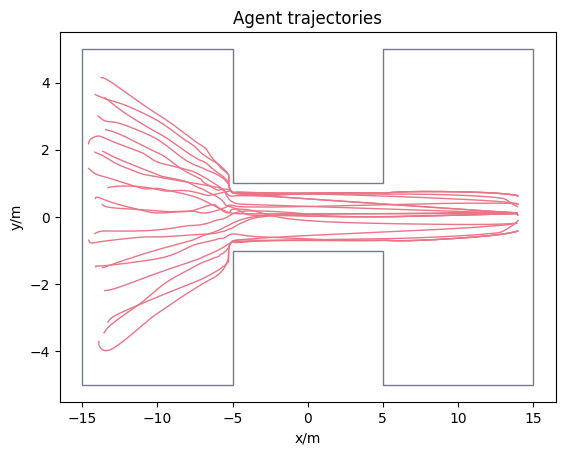

In [32]:
import pedpy

traj = pedpy.TrajectoryData(df, frame_rate=result.frame_rate)
walkable_area = pedpy.WalkableArea(scenario.walkable_polygon)

pedpy.plot_trajectories(
    walkable_area=walkable_area,
    traj=traj,
).set_title("Agent trajectories")

## 6. Parameter sweep — compare seeds

In [33]:
seeds = [1, 2, 3, 4, 5]
evac_times = []

for s in seeds:
    r = run_scenario(scenario, seed=s)
    evac_times.append(r.evacuation_time)
    r.cleanup()
    print(f"  Seed {s}: {r.evacuation_time:.2f}s")

print(f"\nMean: {sum(evac_times)/len(evac_times):.2f}s, "
      f"Min: {min(evac_times):.2f}s, Max: {max(evac_times):.2f}s")

  Seed 1: 34.26s
  Seed 2: 34.45s
  Seed 3: 28.97s
  Seed 4: 31.63s
  Seed 5: 29.37s

Mean: 31.74s, Min: 28.97s, Max: 34.45s


## 7. Parameter sweep — compare agent counts

5 agents: 25.13s
10 agents: 25.29s
20 agents: 33.37s
30 agents: 34.69s


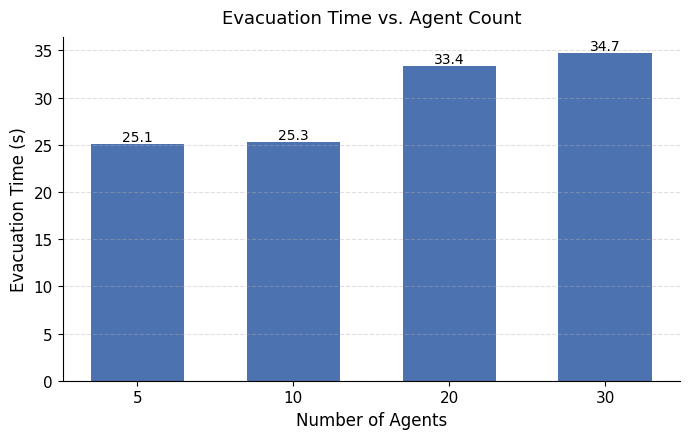

In [34]:
import matplotlib.pyplot as plt

scenario_fresh = load_scenario("scenarios/jps_2026_03_07_10_54_07.zip")
counts = [5, 10, 20, 30]
results_by_count = {}

for n in counts:
    scenario_fresh.set_agent_count("jps-distributions_0", n)
    r = run_scenario(scenario_fresh)
    results_by_count[n] = r.evacuation_time
    r.cleanup()
    print(f"{n} agents: {r.evacuation_time:.2f}s")

times = [results_by_count[n] for n in counts]

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    [str(n) for n in counts],
    times,
    color="#4C72B0",
    width=0.6
)

ax.set_xlabel("Number of Agents", fontsize=12)
ax.set_ylabel("Evacuation Time (s)", fontsize=12)
ax.set_title("Evacuation Time vs. Agent Count", fontsize=13, pad=10)

ax.tick_params(axis="both", labelsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.4)

# cleaner axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Cleanup

In [ ]:
result.cleanup()
print("Done.")